In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from ipywidgets import interact

In [28]:
df = pd.read_csv('reservations.csv', sep=';')

In [29]:
print(df.dtypes)

ID_AGENCY                   int64
VALUE_DATE                 object
NB_RESERVATIONS_1_WEEK      int64
NB_REF_PROMO              float64
MEAN_PCT_PROMO            float64
MEAN_DURATION_PROMO       float64
NB_SPECIAL_PRICES         float64
SALES_GRID_INCREASE       float64
ACTIVITY_POTENTIAL        float64
dtype: object


In [30]:
df['VALUE_DATE'] = pd.to_datetime(df['VALUE_DATE'], format='%d/%m/%Y')


In [31]:
print(df.isna().sum(),'\n')
print(df.duplicated().sum())

ID_AGENCY                   0
VALUE_DATE                  0
NB_RESERVATIONS_1_WEEK      0
NB_REF_PROMO              458
MEAN_PCT_PROMO            458
MEAN_DURATION_PROMO       458
NB_SPECIAL_PRICES         458
SALES_GRID_INCREASE       235
ACTIVITY_POTENTIAL          0
dtype: int64 

0


In [32]:
df.describe()

,ID_AGENCY,VALUE_DATE,NB_RESERVATIONS_1_WEEK,NB_REF_PROMO,MEAN_PCT_PROMO,MEAN_DURATION_PROMO,NB_SPECIAL_PRICES,SALES_GRID_INCREASE,ACTIVITY_POTENTIAL
count,3975.000000,3975,3975.000000,3517.000000,3517.0,3517.000000,3517.000000,3740.000000,3975.000000
mean,128.613082,2024-09-01 15:32:49.811320832,9.223648,9.499005,50.0,2.361624,3.288883,114.934696,0.922798
min,97.000000,2024-01-01 00:00:00,0.000000,1.000000,50.0,1.000000,0.000000,80.453214,0.000000
25%,111.000000,2024-04-29 00:00:00,5.000000,4.000000,50.0,2.000000,0.000000,111.736563,0.929750
50%,125.000000,2024-09-02 00:00:00,8.000000,8.000000,50.0,2.333333,0.000000,115.426545,0.998100
75%,138.500000,2025-01-06 00:00:00,12.000000,14.000000,50.0,3.000000,6.000000,119.199707,1.000000
max,176.000000,2025-04-28 00:00:00,52.000000,34.000000,50.0,3.000000,24.000000,137.306693,1.000000
std,22.601318,NaN,6.709070,6.270796,0.0,0.606554,5.124127,8.314353,0.174064


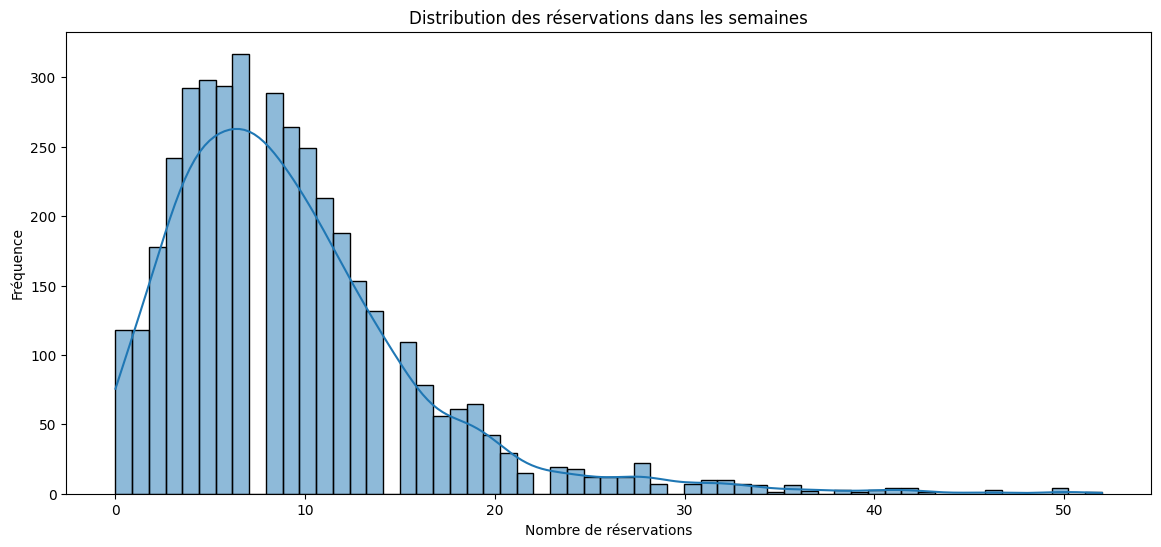

In [33]:
plt.figure(figsize=(14, 6))
sns.histplot(df['NB_RESERVATIONS_1_WEEK'], kde=True)
plt.title("Distribution des réservations dans les semaines")
plt.xlabel('Nombre de réservations')
plt.ylabel('Fréquence')
plt.show()

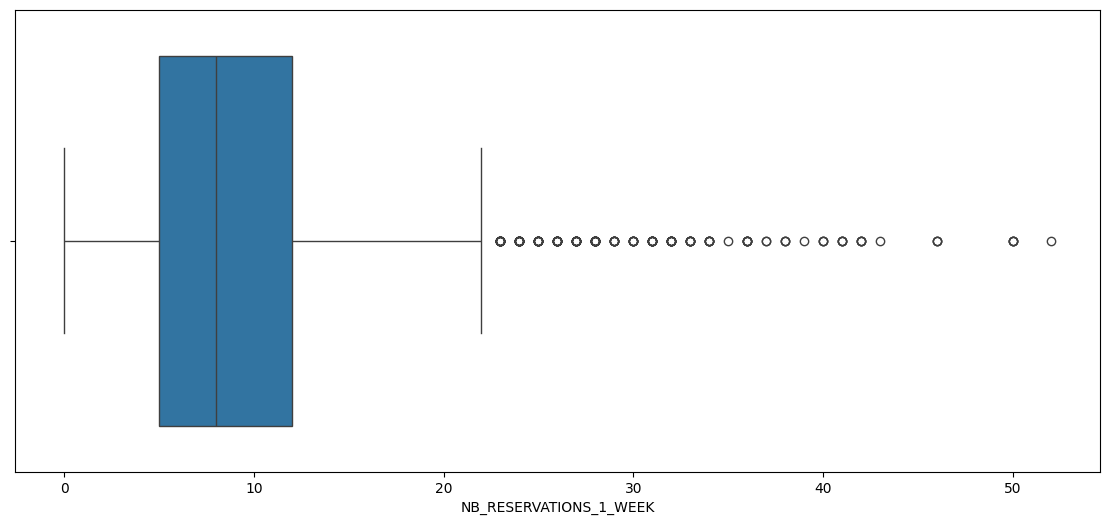

In [34]:
plt.figure(figsize=(14,6))
sns.boxplot(x=df["NB_RESERVATIONS_1_WEEK"])
plt.show()



In [35]:
q1 = df['NB_RESERVATIONS_1_WEEK'].quantile(0.25)
q3 = df['NB_RESERVATIONS_1_WEEK'].quantile(0.75)
iqr = q3-q1

outliers = df[
    (df['NB_RESERVATIONS_1_WEEK'] < q1-1.5*iqr) |
    (df['NB_RESERVATIONS_1_WEEK'] > q3+1.5*iqr)
]
print(outliers.shape[0])

175


Text(0.5, 1.0, 'Réservations mensuelles')

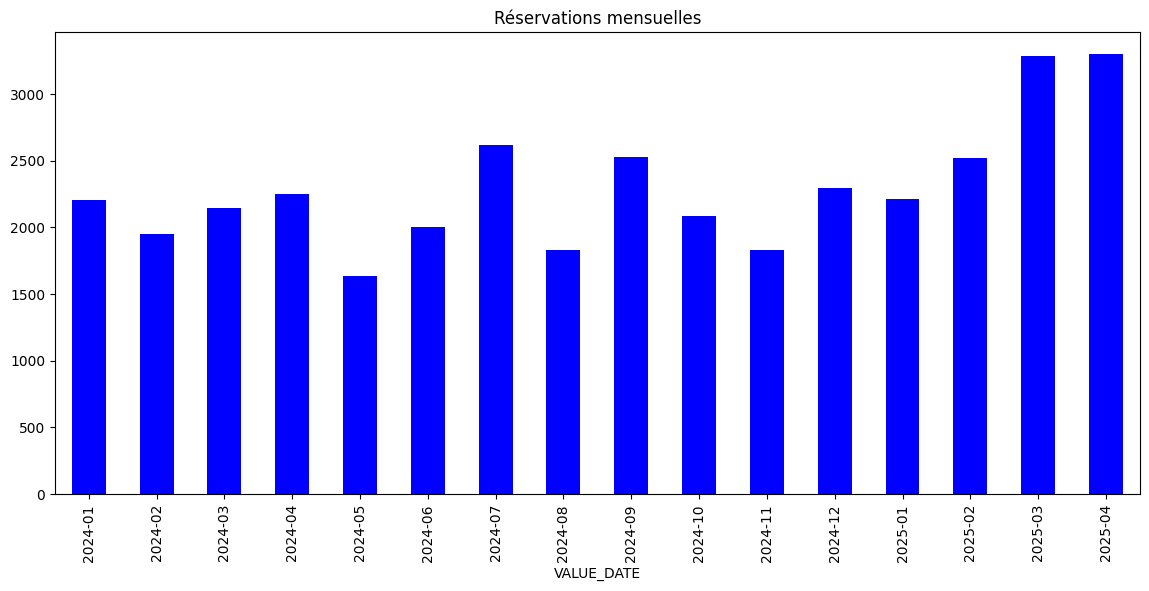

In [36]:
reservations_mensuelles = df.groupby([df['VALUE_DATE'].dt.to_period('M')])['NB_RESERVATIONS_1_WEEK'].sum()
reservations_mensuelles.plot(kind='bar', figsize=(14, 6), color='blue')
plt.title("Réservations mensuelles")

Text(0.5, 1.0, 'Réservations hebdomadaires')

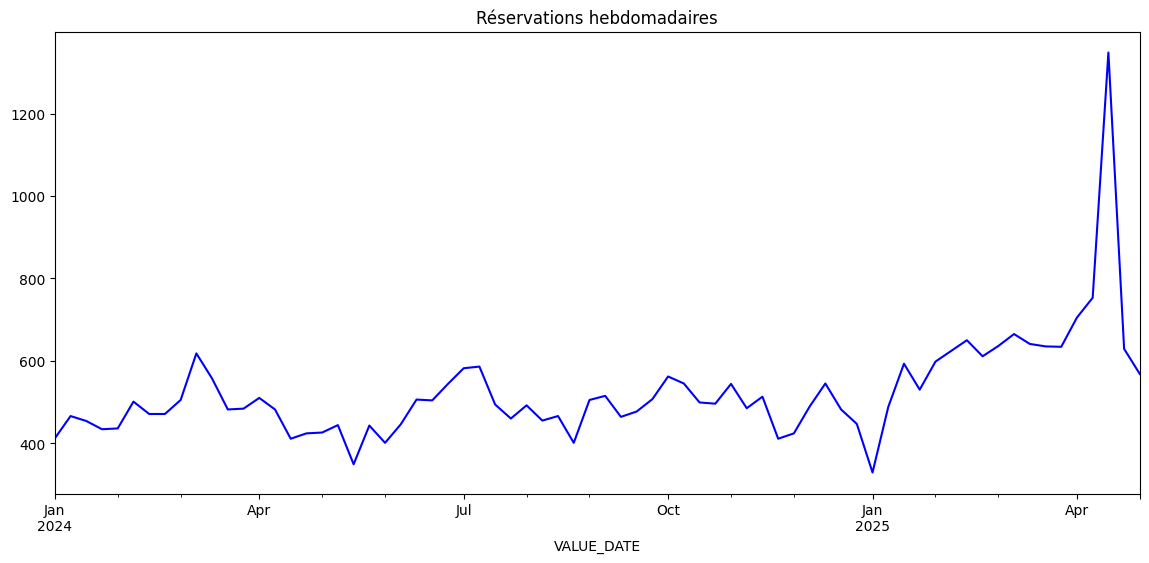

In [37]:
reservations_hebdo = df.groupby([df['VALUE_DATE'].dt.to_period('W')])['NB_RESERVATIONS_1_WEEK'].sum()
reservations_hebdo.plot(kind='line', figsize=(14, 6), color='blue')
plt.title("Réservations hebdomadaires")

In [38]:
reservations_par_agence = df.groupby('ID_AGENCY')['NB_RESERVATIONS_1_WEEK'].mean()

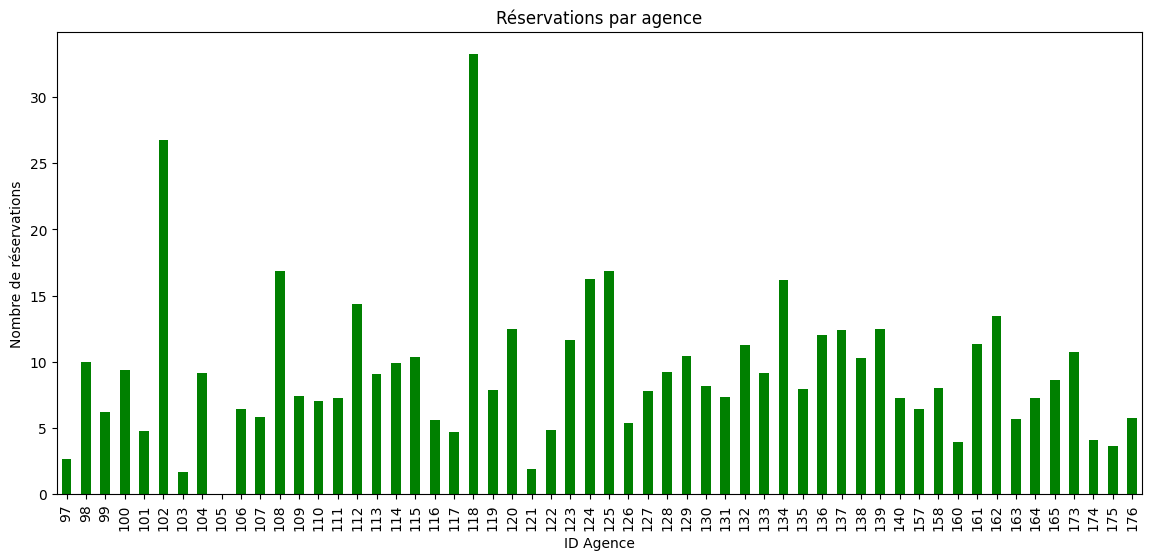

In [39]:
reservations_par_agence.plot(kind='bar', figsize=(14, 6), color='green')
plt.title("Réservations par agence")
plt.xlabel('ID Agence')
plt.ylabel('Nombre de réservations')
plt.show()

In [40]:
df.shape

(3975, 9)

In [41]:
df = df.drop(df[df['ID_AGENCY']==105].index)
df.shape

(3905, 9)

In [42]:
print(df.isna().sum(),'\n')


ID_AGENCY                   0
VALUE_DATE                  0
NB_RESERVATIONS_1_WEEK      0
NB_REF_PROMO              388
MEAN_PCT_PROMO            388
MEAN_DURATION_PROMO       388
NB_SPECIAL_PRICES         388
SALES_GRID_INCREASE       165
ACTIVITY_POTENTIAL          0
dtype: int64 



In [43]:
print(f"median de SALES_GRID_INCREASE est :{df['SALES_GRID_INCREASE'].median()}")
print(f"moyenne de SALES_GRID_INCREASE est {df['SALES_GRID_INCREASE'].mean()}")

median de SALES_GRID_INCREASE est :115.42654467640564
moyenne de SALES_GRID_INCREASE est 114.93469566811676


In [44]:
cols = ['NB_REF_PROMO','MEAN_PCT_PROMO','MEAN_DURATION_PROMO','NB_SPECIAL_PRICES']
for col in cols:
    df[col] = df[col].fillna(0)
    
df['SALES_GRID_INCREASE'] = df['SALES_GRID_INCREASE'].fillna(df['SALES_GRID_INCREASE'].mean())

<Axes: >

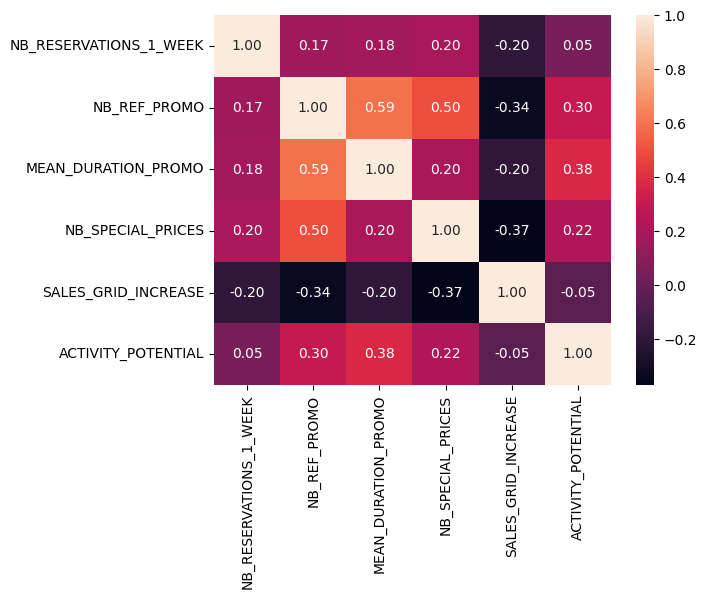

In [45]:
corr = df.drop(['ID_AGENCY','VALUE_DATE','MEAN_PCT_PROMO'], axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f')

Text(0, 0.5, "Potentiel d'activité")

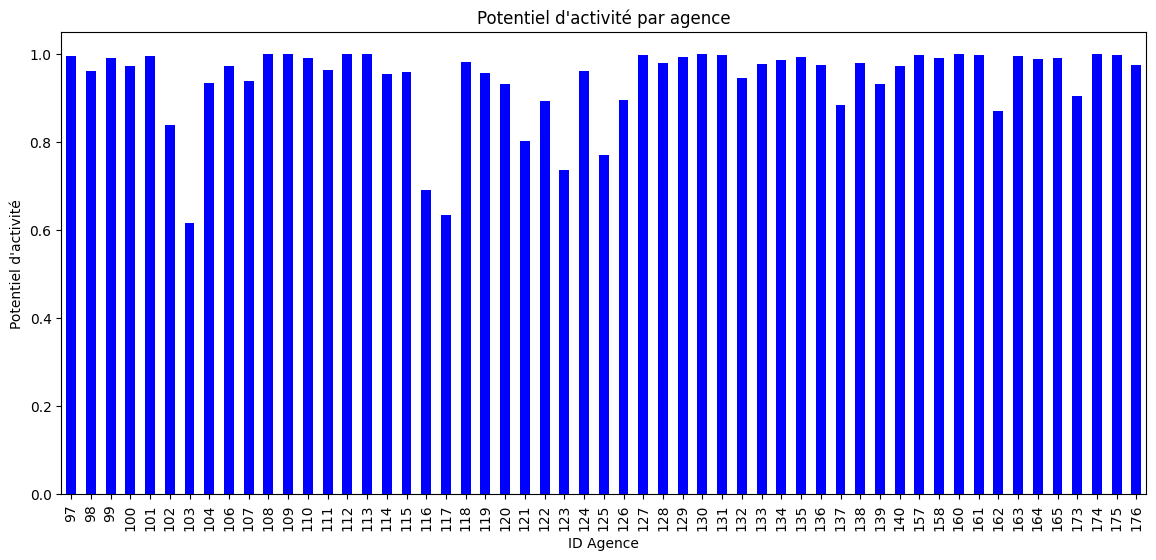

In [48]:
potentiel_par_agence = df.groupby('ID_AGENCY')['ACTIVITY_POTENTIAL'].mean()
potentiel_par_agence.plot(kind='bar', figsize=(14, 6), color='blue')
plt.title("Potentiel d'activité par agence")
plt.xlabel('ID Agence')
plt.ylabel('Potentiel d\'activité')

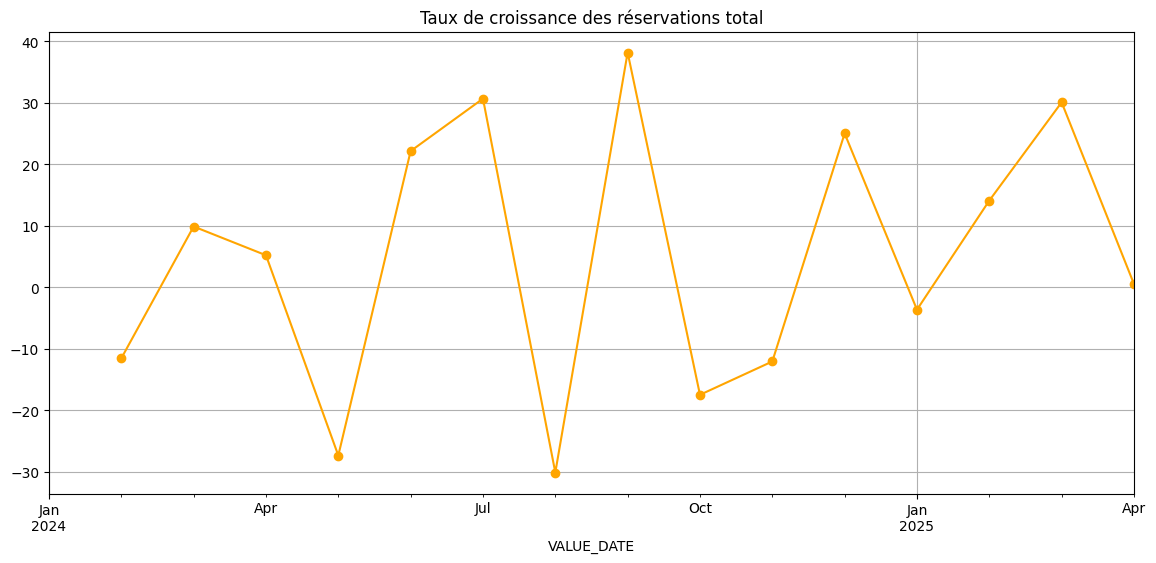

In [49]:
taux_croissance_reservations = reservations_mensuelles.pct_change() * 100
taux_croissance_reservations.plot(kind='line', figsize=(14, 6), color='orange', marker='o', linestyle='-')
plt.title("Taux de croissance des réservations total")
plt.grid(True)
plt.show()


In [50]:
taux_croissance_reservations

VALUE_DATE
2024-01          NaN
2024-02   -11.534968
2024-03     9.907598
2024-04     5.231200
2024-05   -27.341323
2024-06    22.174710
2024-07    30.700000
2024-08   -30.107116
2024-09    38.204707
2024-10   -17.465347
2024-11   -12.044146
2024-12    25.040917
2025-01    -3.621291
2025-02    14.124038
2025-03    30.107100
2025-04     0.548780
Freq: M, Name: NB_RESERVATIONS_1_WEEK, dtype: float64

In [51]:
df['mois'] = df['VALUE_DATE'].dt.to_period('M')

def plot_taux_croissance_par_agence(ID_AGENCY):
    df_agency = df[df['ID_AGENCY'] == ID_AGENCY]
    reservations_par_mois = df_agency.groupby('mois')['NB_RESERVATIONS_1_WEEK'].sum()

    taux_croissance = reservations_par_mois.pct_change() * 100
   
    plt.figure(figsize=(10, 6))
    plt.plot(taux_croissance.index.astype(str), taux_croissance, marker='o', linestyle='-')
    plt.title(f"Taux de croissance des réservations - Agence {ID_AGENCY}")
    plt.xlabel("Mois")
    plt.ylabel("Taux de croissance (%)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

ID_AGENCY = df['ID_AGENCY'].unique()
interact(plot_taux_croissance_par_agence, ID_AGENCY=ID_AGENCY)

interactive(children=(Dropdown(description='ID_AGENCY', options=(np.int64(97), np.int64(98), np.int64(99), np.…

<function __main__.plot_taux_croissance_par_agence(ID_AGENCY)>

# Analyse des séries temporelles

In [52]:
df_time_series = df.set_index('VALUE_DATE')

In [ ]:
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import pandas as pd

variables = ['NB_RESERVATIONS_1_WEEK', 'NB_REF_PROMO', 'MEAN_DURATION_PROMO',
'NB_SPECIAL_PRICES', 'SALES_GRID_INCREASE', 'ACTIVITY_POTENTIAL']

def plot_by_agency(ID_AGENCY):
    df_agency = df_time_series[df_time_series['ID_AGENCY'] == ID_AGENCY]
    df_grouped = df_agency[variables].groupby(df_agency.index).mean()

    # Normalisation entre 0 et 100
    scaler = MinMaxScaler(feature_range=(0, 100))
    df_scaled = pd.DataFrame(scaler.fit_transform(df_grouped), 
                            columns=variables, 
                            index=df_grouped.index)

    fig = go.Figure()
    for var in variables:
        fig.add_trace(go.Scatter(
            x=df_scaled.index,
            y=df_scaled[var],
            mode='lines+markers',
            name=var
        ))
    fig.update_layout(
        title=f'Comparaison normalisée des variables (ID_AGENCY: {ID_AGENCY})',
        xaxis_title='VALUE_DATE',
        yaxis_title='Valeur normalisée (0-100)',
        xaxis=dict(tickangle=-45),
        template='plotly_dark',
        legend=dict(title='Variables')
    )

    fig.show()
   

ID_AGENCY=df['ID_AGENCY'].unique()
interact(plot_by_agency, ID_AGENCY=ID_AGENCY)

# Variables explicatives

In [58]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import category_encoders as ce


#  One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['ID_AGENCY']) # Parfait pour les modèles basés sur des arbres (RandomForest, XGBoost).mais bq de colonnes

# OrdinalEncoder
oe = OrdinalEncoder()
df['ID_AGENCY_ORDINAL'] = oe.fit_transform(df[['ID_AGENCY']]) # probléme : Les modèles pensent que les agences ont un ordre logique, ce qui est faux.

#Leave-One-Out Encoding (LOO)
# elle encode une variable catégorielle (ID_AGENCY) en capturant son comportement moyen sans utiliser l'information cible(reseravtion_week) exacte de la ligne actuelle.
# Idéal pour éviter le surapprentissage, tout en exploitant des moyennes cibles.Si on encode avec LOO, on donne une estimation basée sur les autres lignes, ce qui est plus proche d'une vraie situation de prédiction.

# encoder = ce.LeaveOneOutEncoder(cols=['ID_AGENCY'])
# df['ID_AGENCY_LOO'] = encoder.fit_transform(df['ID_AGENCY'], df['NB_RESERVATIONS_1_WEEK'])





In [88]:
base_features = [
    "NB_REF_PROMO", "MEAN_PCT_PROMO", "MEAN_DURATION_PROMO",
    "NB_SPECIAL_PRICES", "SALES_GRID_INCREASE", "ACTIVITY_POTENTIAL"
]

agency_features = [col for col in df_encoded.columns if col.startswith("ID_AGENCY_")]


features = base_features + ['ID_AGENCY_ORDINAL'] #+['ID_AGENCY_LOO'] +agency_features
target = "NB_RESERVATIONS_1_WEEK"
X = df[features]
y = df[target]

# X = df_encoded[features]
# y = df_encoded[target]



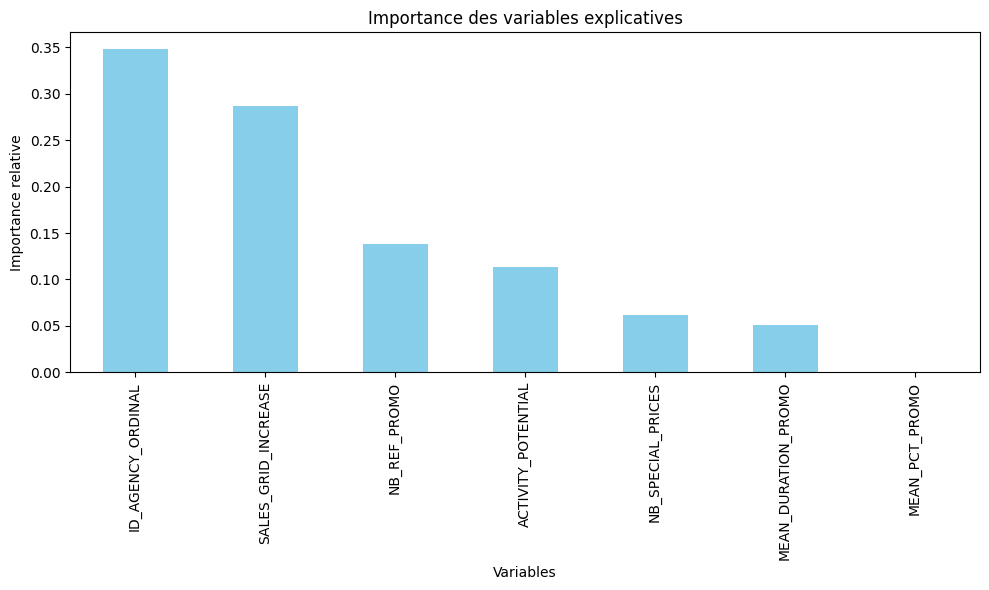

ID_AGENCY_ORDINAL      0.348877
SALES_GRID_INCREASE    0.286815
NB_REF_PROMO           0.138024
ACTIVITY_POTENTIAL     0.113418
NB_SPECIAL_PRICES      0.061459
MEAN_DURATION_PROMO    0.050958
MEAN_PCT_PROMO         0.000450
dtype: float64
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

#  Importance des variables
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)
# avec les features one-hot encodées
# feature_importance = pd.Series(importances, index=base_features + agency_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='skyblue')
plt.title("Importance des variables explicatives")
plt.ylabel("Importance relative")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()

print(feature_importance)
print(model.get_params())



In [61]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
models = {
    # "LinearRegression": LinearRegression(),
     "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]),
    
    'LGBMRegressor': LGBMRegressor(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0), 
}


param_grid = {
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [None, 10],
        'min_samples_split': [2, 5]
    },
    "Gradient Boosting": {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },
    "LGBMRegressor": {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [5, 10],
        'verbose': [-1]
    },
    "XGBoost": {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 6]
    },
}

results = []
best_models = {}

for name, model in models.items():
    print(f"Traitement du modèle : {name}")
    
    if name in param_grid:
        grid = GridSearchCV(model, param_grid[name], cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        print(f"Meilleurs paramètres pour {name} : {grid.best_params_}")
    else:
        model.fit(X_train, y_train)
        best_model = model  # Pas de tuning
    
    y_pred = best_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append((name, mse, r2, rmse, mae))
    best_models[name] = best_model

for name, mse, r2, rmse, mae in results:
    print(f"{name:<18} - R²: {r2:.3f} | MSE: {mse:.2f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")
    
# results = []
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     mse = mean_squared_error(y_test, y_pred)
#     rmse = np.sqrt(mse)
#     r2 = r2_score(y_test, y_pred)
#     mae = mean_absolute_error(y_test, y_pred)
#     results.append((name, mse, r2,rmse,mae))
# for name, mse, r2,rmse,mae in results:
#     print(f"{name} - R²: {r2:.3f} | MSE: {mse:.2f} |RMSE: {rmse:.3f} | MAE: {mae:.2f}")
    
# for name, model in models.items():
#     if hasattr(model, "feature_importances_"):
#         importances = model.feature_importances_

Traitement du modèle : LinearRegression
Traitement du modèle : LGBMRegressor
Meilleurs paramètres pour LGBMRegressor : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'verbose': -1}
Traitement du modèle : Random Forest
Meilleurs paramètres pour Random Forest : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Traitement du modèle : Gradient Boosting
Meilleurs paramètres pour Gradient Boosting : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Traitement du modèle : XGBoost
Meilleurs paramètres pour XGBoost : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
LinearRegression   - R²: 0.092 | MSE: 40.95 | RMSE: 6.40 | MAE: 4.60
LGBMRegressor      - R²: 0.702 | MSE: 13.44 | RMSE: 3.67 | MAE: 2.77
Random Forest      - R²: 0.695 | MSE: 13.76 | RMSE: 3.71 | MAE: 2.81
Gradient Boosting  - R²: 0.687 | MSE: 14.12 | RMSE: 3.76 | MAE: 2.82
XGBoost            - R²: 0.689 | MSE: 14.05 | RMSE: 3.75 | MAE: 2.82


### Prediction par agence 

In [63]:

agency_models = {}
results = []

for agency_id in df['ID_AGENCY'].unique():
    df_agency = df[df['ID_AGENCY'] == agency_id]

    # Features + cible
    X = df_agency[base_features]
    y = df_agency[target]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Modèle
    model = LGBMRegressor(random_state=42)
    model.fit(X_train, y_train)

    # Évaluation
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    agency_models[agency_id] = model
    results.append({
        'ID_AGENCY': agency_id,
        'R2': r2,
        'MSE': mse,
        'MAE': mae
    })

# performances
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print(results_df)

    ID_AGENCY        R2        MSE       MAE
41        139  0.320421  17.022705  3.089829
11        109  0.318852  11.697576  3.099519
21        119  0.223484   8.538223  2.249687
17        115  0.205576  14.066599  3.309594
16        114  0.204466  11.632476  2.623581
26        124  0.173740  20.454515  3.577139
14        112  0.159744   9.575186  2.532593
52        174  0.146528   6.084308  1.781686
49        164  0.117245  13.441417  2.518167
31        129  0.117202  13.512697  3.242006
29        127  0.084710   7.175871  2.367338
51        173  0.073873  17.468805  3.389636
4         101  0.065742   3.919731  1.527586
28        126  0.064645   6.385354  2.094751
45        160  0.063650   4.303046  1.749743
27        125  0.062790  42.636793  5.902228
33        131  0.051864   6.506320  1.972490
0          97  0.044092   1.758871  1.052059
36        134  0.029084  19.789419  3.943099
8         106  0.027535  12.473488  3.024774
22        120  0.023452  39.539355  5.303711
6         

# Analyse en Composantes Principales (PCA)


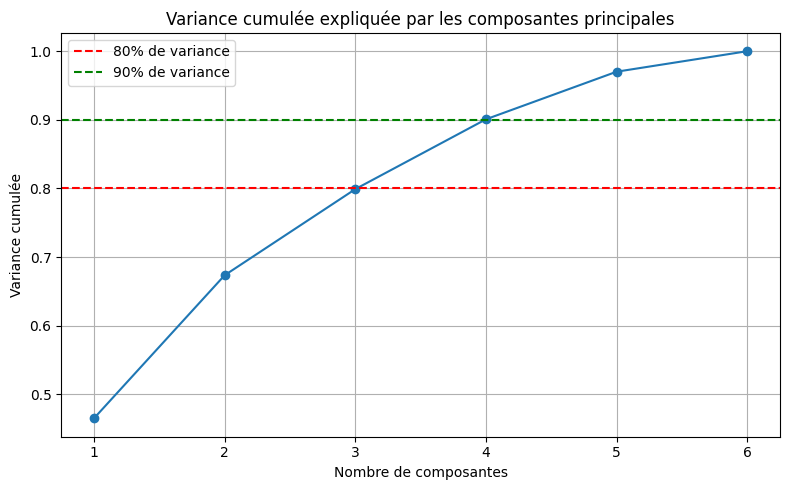

In [89]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. standarlisation les données (important pour le PCA)
X = df[base_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()


plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% de variance')
plt.axhline(y=0.9, color='g', linestyle='--', label='90% de variance')
plt.title("Variance cumulée expliquée par les composantes principales")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [90]:
pca = PCA(n_components = 4)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_


def plot_pca(pc_x =1, pc_y=2):
    if pc_x == pc_y:
        print("Les composantes doivent être différentes.")
        return
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=X_pca[:, pc_x-1],
        y=X_pca[:, pc_y-1],
        mode='markers',
        marker=dict(
            color=y, 
             size=10,          
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title='NB_RESERVATIONS_1_WEEK'),
            opacity=0.6
        ),
        text=[f'Reservation: {val}' for val in y]  
    ))

    fig.update_layout(
        title='PCA - Projection des données',
        xaxis_title=f'PC{pc_x} ({explained_var[pc_x-1]:.2%} variance)',
        yaxis_title=f'PC{pc_y} ({explained_var[pc_y-1]:.2%} variance)',
        width=1200,
        height=600,
        template='plotly_dark'
    )

    fig.show()
    
    # plt.figure(figsize=(10,6))
    # plt.scatter(X_pca[:, pc_x-1], X_pca[:, pc_y-1], c=y, cmap='viridis', alpha=0.7)
    # plt.xlabel(f'PC{pc_x} ({explained_var[pc_x-1]:.2%})')
    # plt.ylabel(f'PC{pc_y} ({explained_var[pc_y-1]:.2%})')
    # plt.title(f'PCA - PC{pc_x} vs PC{pc_y}')
    # plt.colorbar(label='NB_RESERVATIONS_1_WEEK')
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()

interact(plot_pca, pc_x=(1,5), pc_y=(1,5))

print(f"Composante 1 : {explained_var[0]:.2%} de la variance expliquée")
print(f"Composante 2 : {explained_var[1]:.2%} de la variance expliquée")
print(f"Composante 3 : {explained_var[2]:.2%} de la variance expliquée")
print(f"Composante 4 : {explained_var[3]:.2%} de la variance expliquée")
print(f"Variance expliquée par les 4 composantes : {sum(explained_var[0:4]):.2%}")


interactive(children=(IntSlider(value=1, description='pc_x', max=5, min=1), IntSlider(value=2, description='pc…

Composante 1 : 46.48% de la variance expliquée
Composante 2 : 20.86% de la variance expliquée
Composante 3 : 12.56% de la variance expliquée
Composante 4 : 10.18% de la variance expliquée
Variance expliquée par les 4 composantes : 90.08%


In [66]:
# Plot 3D : PC1 vs PC2 vs PC3
fig = go.Figure(data=[go.Scatter3d(
    x=X_pca[:, 0],  # PC1
    y=X_pca[:, 1],  # PC2
    z=X_pca[:, 2],  # PC3
    mode='markers',
    marker=dict(
        size=8,
        color=y,  # Couleur selon NB_RESERVATIONS_1_WEEK
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='NB_RESERVATIONS_1_WEEK')
    ),
    text=[f'Reservation: {val}' for val in y]
)])

fig.update_layout(
    title=f'PCA 3D - PC1 ({explained_var[0]:.2%}), PC2 ({explained_var[1]:.2%}), PC3 ({explained_var[2]:.2%})',
    scene=dict(
        xaxis_title=f'PC1 ({explained_var[0]:.2%})',
        yaxis_title=f'PC2 ({explained_var[1]:.2%})',
        zaxis_title=f'PC3 ({explained_var[2]:.2%})'
    ),
    template='plotly_dark',
    width=1200,
    height=900
)

fig.show()

In [91]:
coefs = pd.DataFrame(
    pca.components_,  
    columns=X.columns, 
    index=[f'PC{i+1}' for i in range(pca.n_components_)]  
)
display(coefs)

print(explained_var)


,NB_REF_PROMO,MEAN_PCT_PROMO,MEAN_DURATION_PROMO,NB_SPECIAL_PRICES,SALES_GRID_INCREASE,ACTIVITY_POTENTIAL
PC1,0.477827,0.470664,0.501470,0.336836,-0.247568,0.352047
PC2,-0.197080,0.390199,0.269854,-0.516919,0.619518,0.291676
PC3,-0.092558,-0.200819,-0.386615,0.434503,0.284645,0.729259
PC4,0.385653,-0.025226,0.034374,0.416081,0.685019,-0.455060


[0.46478823 0.20856568 0.12557629 0.10182614]


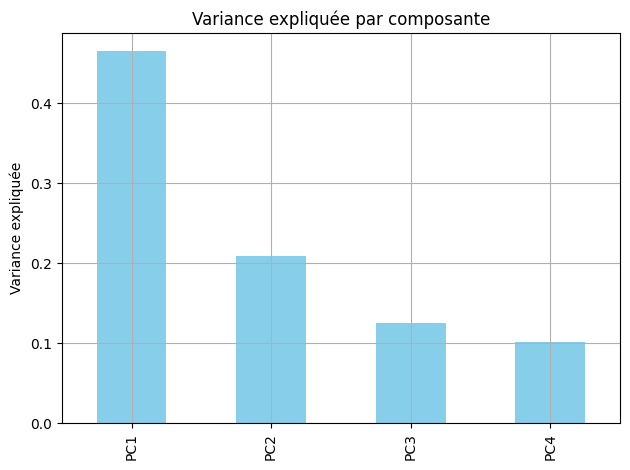

In [92]:
pd.Series(explained_var, index=[f"PC{i+1}" for i in range(len(explained_var))]).plot(kind='bar', color='skyblue')
plt.title("Variance expliquée par composante")
plt.ylabel("Variance expliquée")
plt.grid(True)
plt.tight_layout()
plt.show()


In [95]:
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(4)])
pca_df['ID_AGENCY'] = df['ID_AGENCY'].astype(str)  

fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',  
    color='ID_AGENCY',
    title='PCA - Projection PC1 vs PC2 (colorée par ID_AGENCY)',
    labels={
        'PC1': f"PC1 ({explained_var[0]:.2%} variance)",
        'PC2': f"PC2 ({explained_var[1]:.2%} variance)"
    },
    opacity=0.7,
    width=1000,
    height=600
)

fig.update_layout(template='plotly_dark')
fig.show()

In [ ]:
pca_df['ID_AGENCY'].unique()

### Clustring

In [72]:
df_agence = df.groupby("ID_AGENCY").mean(numeric_only=True).reset_index()

X = df_agence.drop(columns=["ID_AGENCY"])  # les variables explicatives
# 3. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_agence)


In [ ]:
df_agence.head()

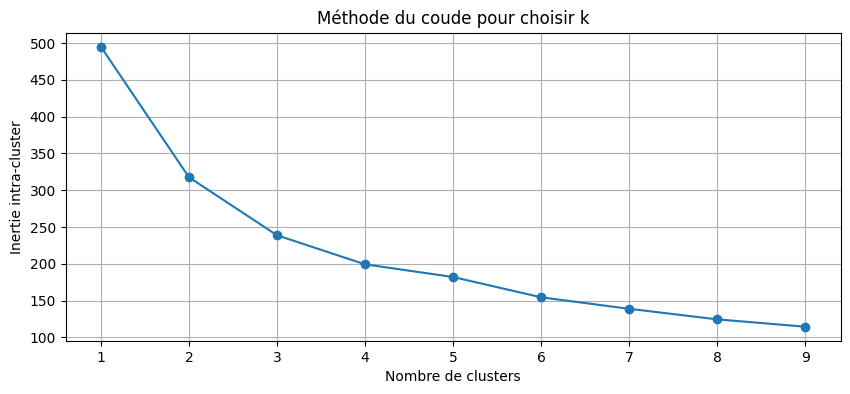

In [73]:
from sklearn.cluster import KMeans
inertias = []
for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10,4))
plt.plot(range(1,10), inertias, marker = 'o')
plt.title("Méthode du coude pour choisir k")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie intra-cluster")
plt.grid(True)
plt.show()    

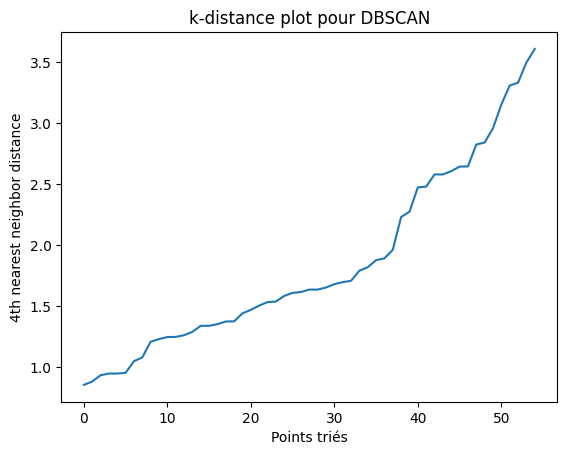

In [74]:
from sklearn.cluster import DBSCAN,OPTICS
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 3])

plt.plot(distances)
plt.ylabel("4th nearest neighbor distance")
plt.xlabel("Points triés")
plt.title("k-distance plot pour DBSCAN")
plt.show()


In [ ]:
xi_values = [0.02, 0.05, 0.1]
min_cluster_sizes = [0.05, 0.1, 0.2]

for xi in xi_values:
    for mcs in min_cluster_sizes:
        optics = OPTICS(min_samples=14, xi=xi, min_cluster_size=mcs)
        labels = optics.fit_predict(X_scaled)
        if len(set(labels)) > 1 and -1 not in labels:
            score = silhouette_score(X_scaled, labels)
            print(f"xi={xi}, min_cluster_size={mcs} → silhouette={score:.3f}, clusters={len(set(labels))}")
        else:
            print(f"xi={xi}, min_cluster_size={mcs} → Clustering peu exploitable")


In [75]:

# KMEANS
n_clusters = 4  
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
df_agence["Cluster_KMEANS"] = labels_kmeans.astype(str)

#kmeans avec pca
X_pca = PCA(n_components=4).fit_transform(X_scaled)
labels_kmeans_pca = KMeans(n_clusters=4,random_state=42,n_init=10).fit_predict(X_pca)
df_agence["Cluster_KMEANS_PCA"] = labels_kmeans_pca.astype(str)

# DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=2*7)  # 7 nb features
labels_dbscan = dbscan.fit_predict(X_scaled)
df_agence["Cluster_DBSCAN"] = labels_dbscan.astype(str)

# OPTICS
optics = OPTICS(min_samples=2*7, xi=0.05, min_cluster_size=0.1)
labels_optics = optics.fit_predict(X_scaled)
df_agence["Cluster_OPTICS"] = labels_optics.astype(str)


In [76]:
print(f"n_clusters_kmeans = {len(np.unique(labels_kmeans_pca[labels_kmeans != -1]))}")

print(f"n_clusters_kmeans_pca = {len(np.unique(labels_kmeans_pca[labels_kmeans_pca != -1]))}")

print(f"n_clusters_dbscan = {len(np.unique(labels_dbscan[labels_dbscan != -1]))}")
print(f"n_noise_dbscan = {np.sum(labels_dbscan == -1)}")

print(f"n_clusters_optics = {len(np.unique(labels_optics[labels_dbscan != -1]))}")
print(f"n_noise_optics = {np.sum(labels_optics == -1)}")


n_clusters_kmeans = 4
n_clusters_kmeans_pca = 4
n_clusters_dbscan = 1
n_noise_dbscan = 12
n_clusters_optics = 1
n_noise_optics = 0


In [77]:
score_kmeans = silhouette_score(X_scaled, labels_kmeans)
score_kmeans_pca = silhouette_score(X_scaled, labels_kmeans_pca)
score_dbscan = silhouette_score(X_scaled, labels_dbscan)
# score_optics = silhouette_score(X_scaled, labels_optics)
print("Silhouette KMeans:", score_kmeans)
print("Silhouette KMeans_pca:", score_kmeans_pca)
print("Silhouette DBSCAN:", score_dbscan)
# print("Silhouette OPTICS:", score_optics)

Silhouette KMeans: 0.2611309093492813
Silhouette KMeans_pca: 0.2611309093492813
Silhouette DBSCAN: 0.38147830713782266


In [78]:
centers_scaled = kmeans.cluster_centers_  
centers_orig   = scaler.inverse_transform(centers_scaled)
cols = df_agence.columns[:X_scaled.shape[1]] 
df_centers     = pd.DataFrame(centers_orig, columns=cols)
df_centers["Cluster_KMEANS"] = range(df_centers.shape[0])
print(df_centers[["Cluster_KMEANS", "NB_RESERVATIONS_1_WEEK", "SALES_GRID_INCREASE"]])
# for col in df_agence.columns:
#     print(f"\n=== {col} ===")
#     print(df_centers.groupby("Cluster_KMEANS")[col].mean())

   Cluster_KMEANS  NB_RESERVATIONS_1_WEEK  SALES_GRID_INCREASE
0               0                8.395540           121.370528
1               1               11.845070           113.657988
2               2                5.408451           116.578735
3               3                9.290744           110.185254


In [79]:
import plotly.express as px

methods = {
    "KMeans": "Cluster_KMEANS",
    "KMeans_PCA": "Cluster_KMEANS_PCA",
    "DBSCAN": "Cluster_DBSCAN",
    "OPTICS": "Cluster_OPTICS"
}

for method_name, cluster_col in methods.items():
    fig = px.scatter(
        df_agence,
        x="NB_RESERVATIONS_1_WEEK",
        y="SALES_GRID_INCREASE",
        color=cluster_col,
        hover_data=["ID_AGENCY"],
        title=f"Clustering des agences - {method_name}",
        labels={
            "NB_RESERVATIONS_1_WEEK",
            "SALES_GRID_INCREASE"
        }
    )
    
    fig.update_traces(marker=dict(size=10))
    fig.update_layout(
        legend_title=cluster_col,
        template='plotly_dark',
        width=1000,
        height=700
    )
    
    fig.show()


### Résumé de clustring

Analyse comparative des méthodes de clustering
Pour segmenter les agences, j’ai testé trois algorithmes de clustering après standardisation des 7 variables explicatives :KMeans,DBSCAN,OPTICS

KMeans
J’ai utilisé la méthode du coude pour déterminer le nombre optimal de clusters, ce qui m’a conduit à fixer n_clusters = 4.
L’algorithme a produit 4 groupes bien définis, sans points considérés comme bruit.
Le score de silhouette obtenu est de 0.2667, indiquant une séparation modeste mais exploitable entre les groupes.
Cette méthode permet une segmentation claire et exploitable, tout en conservant la totalité des données.

KMeans avec PCA
Une réduction dimensionnelle par ACP (PCA) a été réalisée avant le clustering.
Les 4 premières composantes expliquent 90,08 % de la variance totale.
Un clustering KMeans a alors été effectué sur ces composantes réduites, avec le même n_clusters = 4.
Le score silhouette obtenu est très proche (0.2671), ce qui montre que la PCA ne dégrade pas la structure des clusters, et peut être utilisée pour simplifier la visualisation ou réduire la complexité.

DBSCAN
J’ai choisi les hyperparamètres comme suit :

eps = 2.5 (déterminé via k-distance plot sur le 4e plus proche voisin)

min_samples = 14 (soit 2 × n_features) la methode typique

DBSCAN a détecté 1 seul cluster, et a classé 11 agences comme bruit.
Bien que le score silhouette soit élevé (0.426), ce résultat est trompeur car il ne reflète qu’un groupe compact entouré de bruit, sans réelle segmentation exploitable.
En pratique, ce résultat est peu utile pour une segmentation métier.

OPTICS
J’ai testé plusieurs combinaisons des hyperparamètres :

min_samples = 14 (2 × 7 features)

xi entre 0.02 et 0.1

min_cluster_size entre 0.05 et 0.2

Quel que soit le réglage, OPTICS a systématiquement détecté un seul cluster, sans points considérés comme bruit.
Cela suggère une homogénéité de densité trop forte dans les données pour que cette méthode fonctionne efficacement ici.
La segmentation produite est donc non exploitable.

Conclusion
KMeans est le meilleur choix dans ce cas : il offre une segmentation interprétable, stable et sans perte de données, malgré un score de silhouette modéré.

DBSCAN et OPTICS ne détectent pas de structure utile : soit 1 seul cluster, soit trop de bruit.

La PCA peut être utilisée en complément, pour simplifier les visualisations ou réduire la complexité sans impacter la qualité du clustering.



